C:\Users\nvleb\AppData\Local\Temp\ipykernel_32388\2935766396.py:23: RuntimeWarning: Mean of empty slice
  dailyRiverTemperatureBottom = np.nanmean(upRiverDF.loc[(upRiverDF['dayDN'] == dateMark) & (upRiverDF["BottomSalCorrected"] < 0.25)]["BottomTemp"])
C:\Users\nvleb\AppData\Local\Temp\ipykernel_32388\2935766396.py:23: RuntimeWarning: Mean of empty slice
  dailyRiverTemperatureBottom = np.nanmean(upRiverDF.loc[(upRiverDF['dayDN'] == dateMark) & (upRiverDF["BottomSalCorrected"] < 0.25)]["BottomTemp"])
C:\Users\nvleb\AppData\Local\Temp\ipykernel_32388\2935766396.py:23: RuntimeWarning: Mean of empty slice
  dailyRiverTemperatureBottom = np.nanmean(upRiverDF.loc[(upRiverDF['dayDN'] == dateMark) & (upRiverDF["BottomSalCorrected"] < 0.25)]["BottomTemp"])
C:\Users\nvleb\AppData\Local\Temp\ipykernel_32388\2935766396.py:23: RuntimeWarning: Mean of empty slice
  dailyRiverTemperatureBottom = np.nanmean(upRiverDF.loc[(upRiverDF['dayDN'] == dateMark) & (upRiverDF["BottomSalCorrected"] < 0.25)]["Bo

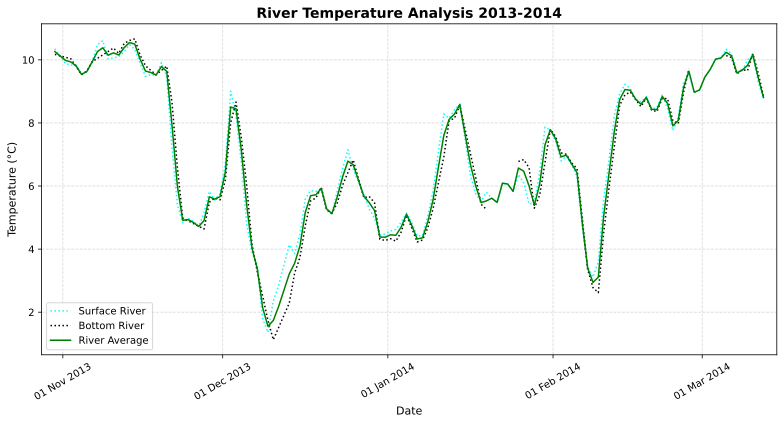

In [1]:
import pandas as pd
import scipy.io as sio
from scipy import signal, stats
import numpy as np
import datetime
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
%config InlineBackend.figure_format = 'svg'

# =====================================================================
# 1. GENERATE BASE RIVER TEMPERATURES
# =====================================================================
upRiverDF = pd.read_csv('upriver_2013_2014_processed.csv', parse_dates=['DN'])
upRiverDF['dayDN'] = upRiverDF['DN'].dt.floor('D')
upRiverDF["surfaceRiver"] = np.nan
upRiverDF["bottomRiver"] = np.nan

dayDN = upRiverDF['dayDN'].drop_duplicates().to_list()
for dateMark in dayDN:
    if upRiverDF.loc[(upRiverDF['dayDN'] == dateMark) & (upRiverDF["SurfaceSalCorrected"] < 0.25)].shape[0] > 0:
        dailyRiverTemperatureSurface = np.nanmean(upRiverDF.loc[(upRiverDF['dayDN'] == dateMark) & (upRiverDF["SurfaceSalCorrected"] < 0.25)]["SurfaceTemp"])
        dailyRiverTemperatureBottom = np.nanmean(upRiverDF.loc[(upRiverDF['dayDN'] == dateMark) & (upRiverDF["BottomSalCorrected"] < 0.25)]["BottomTemp"])
    else:
        # Linear regression for Surface
        (slopeSurface, interceptSurface, rSurface, p, std_err) = stats.linregress(
            upRiverDF.loc[upRiverDF['dayDN'] == dateMark]["SurfaceSalCorrected"].ffill().bfill().to_numpy(), 
            upRiverDF.loc[upRiverDF['dayDN'] == dateMark]["SurfaceTemp"].ffill().bfill().to_numpy(), alternative="less"
        )
        
        if abs(rSurface) < 0.2:
            dailyRiverTemperatureSurface = np.nan 
        else:
            dailyRiverTemperatureSurface = interceptSurface
        
        # Linear regression for Bottom
        (slopeBottom, interceptBottom, rBottom, p, std_err) = stats.linregress(
            upRiverDF.loc[upRiverDF['dayDN'] == dateMark]["BottomSalCorrected"].ffill().bfill().to_numpy(), 
            upRiverDF.loc[upRiverDF['dayDN'] == dateMark]["BottomTemp"].ffill().bfill().to_numpy(), alternative="less"
        )
        
        if abs(rBottom) < 0.2:
            dailyRiverTemperatureBottom = np.nan
        else:
            dailyRiverTemperatureBottom = interceptBottom

    upRiverDF.loc[upRiverDF['dayDN'] == dateMark, "surfaceRiver"] = dailyRiverTemperatureSurface
    upRiverDF.loc[upRiverDF['dayDN'] == dateMark, "bottomRiver"] = dailyRiverTemperatureBottom

# Vectorized Daily Average Calculation
upRiverDF["EstimatedTemp"] = upRiverDF[["surfaceRiver", "bottomRiver"]].mean(axis=1)

# Save stable base file
upRiverDF.to_csv('river_temperature13_14.csv', index=False)

# =====================================================================
# 2. CLEAN TIMELINE ALIGNMENT
# =====================================================================
riverTempDF = upRiverDF.copy()

# =====================================================================
# 3. DEDUPLICATE AND CONDITIONALLY INTERPOLATE SURFACE & BOTTOM GAPS
# =====================================================================
plotting_df = riverTempDF.copy()

# Preserve 'DN' for flooring
plotting_df['date_day'] = plotting_df['DN'].dt.floor('D')

# Grouping daily values (1 row = 1 calendar day)
plotting_df = plotting_df.groupby('date_day')[['surfaceRiver', 'bottomRiver', 'EstimatedTemp']].mean().reset_index()

# --- A. CONDITIONAL INTERPOLATION FOR BOTTOM RIVER ---
is_nan_bottom = plotting_df['bottomRiver'].isna()
gap_ids_bottom = (~is_nan_bottom).cumsum()
gap_sizes_bottom = gap_ids_bottom.map(gap_ids_bottom[is_nan_bottom].value_counts())
interpolated_bottom = plotting_df['bottomRiver'].interpolate(method='linear')
plotting_df['bottomRiver'] = np.where(
    is_nan_bottom & (gap_sizes_bottom >= 4), 
    np.nan, 
    interpolated_bottom
)

# --- B. CONDITIONAL INTERPOLATION FOR SURFACE RIVER ---
is_nan_surface = plotting_df['surfaceRiver'].isna()
gap_ids_surface = (~is_nan_surface).cumsum()
gap_sizes_surface = gap_ids_surface.map(gap_ids_surface[is_nan_surface].value_counts())
interpolated_surface = plotting_df['surfaceRiver'].interpolate(method='linear')
plotting_df['surfaceRiver'] = np.where(
    is_nan_surface & (gap_sizes_surface >= 4), 
    np.nan, 
    interpolated_surface
)

# --- C. RECALCULATE ESTIMATED TEMPERATURE AFTER GAP CORRECTION ---
plotting_df["EstimatedTemp"] = plotting_df[["surfaceRiver", "bottomRiver"]].mean(axis=1)
plotting_df['EstimatedTemp'] = plotting_df['EstimatedTemp'].interpolate(method='linear')

# Position metrics at exactly noon to perfectly center line graphs visually
plotting_df['plot_date'] = plotting_df['date_day'] + pd.Timedelta(hours=12)

# =====================================================================
# 4. MATPLOTLIB RENDER
# =====================================================================
fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(plotting_df['plot_date'], plotting_df['surfaceRiver'], 
        color='cyan', linestyle=':', linewidth=1.5, label='Surface River')

ax.plot(plotting_df['plot_date'], plotting_df['bottomRiver'], 
        color='black', linestyle=':', linewidth=1.5, label='Bottom River')

ax.plot(plotting_df['plot_date'], plotting_df['EstimatedTemp'], 
        color='green', linewidth=1.5, label='River Average')

# Aesthetics and Bounds
ax.set_title('River Temperature Analysis 2013-2014', fontsize=14, fontweight='bold')
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Temperature (°C)', fontsize=11)
ax.set_xlim(pd.Timestamp('2013-10-28'), pd.Timestamp('2014-03-15'))

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
plt.xticks(rotation=30)
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(loc='lower left', frameon=True)

plt.tight_layout()
plt.show()

plotting_df.to_csv('FINALIZED_river_temperature13_14.csv', index=False)
